In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [4]:
df = pd.read_csv("/content/vgsales.csv")
df.head()
df.shape

(16598, 11)

In [6]:
df.isnull().sum()

,0
Rank,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


In [7]:
df = df.dropna()

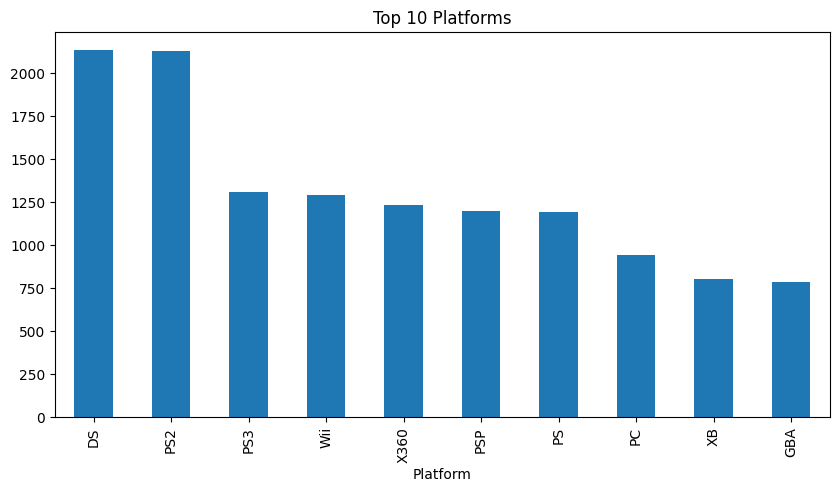

In [8]:
plt.figure(figsize=(10,5))
df['Platform'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Platforms")
plt.show()

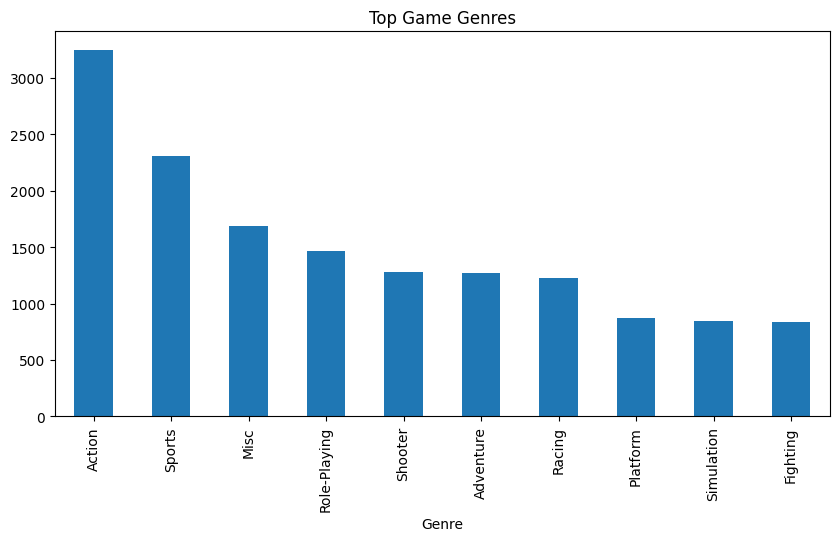

In [9]:
plt.figure(figsize=(10,5))
df['Genre'].value_counts().head(10).plot(kind='bar')
plt.title("Top Game Genres")
plt.show()

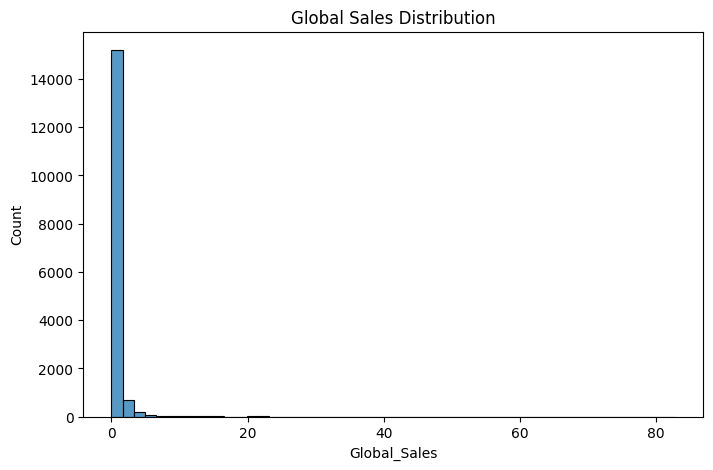

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Global_Sales'], bins=50)
plt.title("Global Sales Distribution")
plt.show()

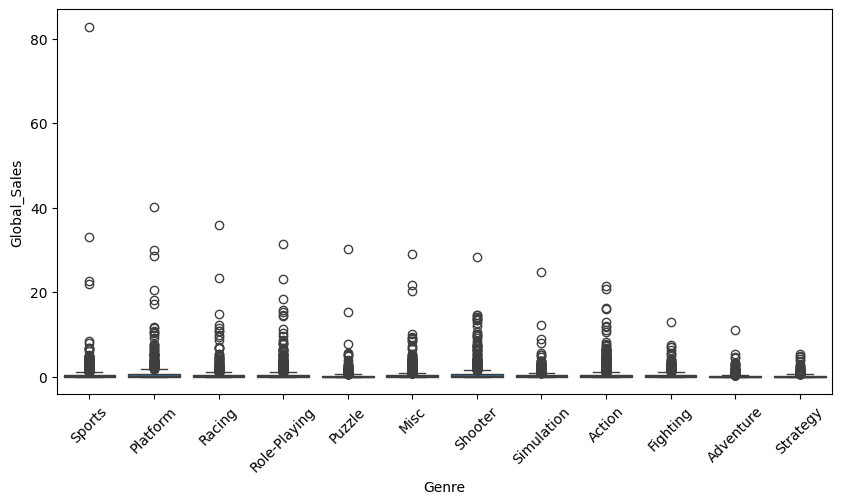

In [11]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Genre', y='Global_Sales', data=df)
plt.xticks(rotation=45)
plt.show()

In [12]:
df_ml = df[['Platform','Genre','Publisher','Year','Global_Sales']]

In [13]:
df_ml = pd.get_dummies(df_ml)

In [14]:
from sklearn.model_selection import train_test_split

X = df_ml.drop("Global_Sales", axis=1)
y = df_ml["Global_Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [16]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [18]:
print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lr)))
print("R2:", r2_score(y_test, pred_lr))

Linear Regression
MAE: 0.5620923730866673
RMSE: 1.9757825637507593
R2: 0.08748336429378278


In [19]:
print("Random Forest")
print("MAE:", mean_absolute_error(y_test, pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))
print("R2:", r2_score(y_test, pred_rf))

Random Forest
MAE: 0.5209897530055528
RMSE: 2.047971128129744
R2: 0.01958453490059653


In [20]:
import joblib

joblib.dump(rf, "game_sales_model.pkl")
joblib.dump(X.columns.tolist(), "features.pkl")

['features.pkl']

In [21]:
import gzip
import shutil

with open("game_sales_model.pkl", "rb") as f_in:
    with gzip.open("game_sales_model.pkl.gz", "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

In [22]:
df_sample = df.sample(5000, random_state=42)
df_sample.to_csv("vgsales_sample.csv", index=False)